<a href="https://colab.research.google.com/github/thanhthuy280501/Data-Visualization/blob/main/Data_visualization_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
gdp_path = '/content/drive/MyDrive/Colab Notebooks/API_NY.GDP.PCAP.PP.CD_DS2_en_excel_v2_589.xls'
pop_path = '/content/drive/MyDrive/Colab Notebooks/API_SP.POP.DPND.OL_DS2_en_excel_v2_2904.xls'
zip_path = '/content/drive/MyDrive/Colab Notebooks/ti-corruption-perception-index.zip'

# Load the datasets
# Note: xlrd or openpyxl might be required for .xls files
df_gdp = pd.read_excel(gdp_path)
df_pop = pd.read_excel(pop_path)

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
import zipfile
import io

with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open('ti-corruption-perception-index.csv') as f:
        df_corruption = pd.read_csv(f)
display(df_corruption.head())

,Entity,Code,Year,Corruption Perceptions Index,World region according to OWID
0,Afghanistan,AFG,2012,8,Asia
1,Afghanistan,AFG,2013,8,Asia
2,Afghanistan,AFG,2014,12,Asia
3,Afghanistan,AFG,2015,11,Asia
4,Afghanistan,AFG,2016,15,Asia


In [ ]:
num_countries = df_corruption['Entity'].nunique()
print(f"There are {num_countries} unique countries in the corruption dataset.")

There are 182 unique countries in the corruption dataset.


In [ ]:
num_regions = df_corruption['World region according to OWID'].nunique()
print(f"There are {num_regions} unique regions in the corruption dataset.")

There are 6 unique regions in the corruption dataset.


In [ ]:
import numpy as np

unique_countries = df_corruption['Entity'].unique()

print("Countries with missing years:")
for country in unique_countries:
    country_data = df_corruption[df_corruption['Entity'] == country]
    years_present = country_data['Year'].unique()
    years_present = np.sort(years_present) # Fixed line: Use np.sort() on the IntegerArray

    if len(years_present) > 1:
        min_year = years_present.min()
        max_year = years_present.max()
        expected_years = np.arange(min_year, max_year + 1)

        missing_years_for_country = np.setdiff1d(expected_years, years_present)

        if len(missing_years_for_country) > 0:
            print(f"  {country}: Missing years {missing_years_for_country.tolist()}")

Countries with missing years:
  Bahamas: Missing years [2015]
  Barbados: Missing years [2015]
  Brunei: Missing years [2014, 2015]
  Dominica: Missing years [2015]
  Equatorial Guinea: Missing years [2014, 2015, 2016]
  Eswatini: Missing years [2015, 2016]
  Saint Lucia: Missing years [2015]
  Saint Vincent and the Grenadines: Missing years [2015]
  Seychelles: Missing years [2016]


In [ ]:
import numpy as np

unique_countries = df_corruption['Entity'].unique()
countries_with_missing_years = []

for country in unique_countries:
    country_data = df_corruption[df_corruption['Entity'] == country]
    years_present = country_data['Year'].unique()
    years_present = np.sort(years_present)

    if len(years_present) > 1:
        min_year = years_present.min()
        max_year = years_present.max()
        expected_years = np.arange(min_year, max_year + 1)

        missing_years_for_country = np.setdiff1d(expected_years, years_present)

        if len(missing_years_for_country) > 0:
            countries_with_missing_years.append(country)

num_countries_with_nan_years = len(countries_with_missing_years)
print(f"There are {num_countries_with_nan_years} countries with missing 'Corruption Perceptions Index' data for some years within their period.")

There are 9 countries with missing 'Corruption Perceptions Index' data for some years within their period.


In [ ]:
grouped_corruption = df_corruption.groupby(['World region according to OWID', 'Year']).agg(
    num_countries=('Entity', 'nunique'),
    avg_corruption_index=('Corruption Perceptions Index', 'mean')
).reset_index()
display(grouped_corruption.head())

,World region according to OWID,Year,num_countries,avg_corruption_index
0,Africa,2012,53,33.320755
1,Africa,2013,54,32.129630
2,Africa,2014,53,32.849057
3,Africa,2015,52,32.307692
4,Africa,2016,51,31.509804


In [ ]:
countries_per_region = df_corruption.groupby('World region according to OWID')['Entity'].nunique().reset_index()
countries_per_region.columns = ['World region', 'Number of Countries']
display(countries_per_region.sort_values(by='Number of Countries', ascending=False))

,World region,Number of Countries
0,Africa,54
1,Asia,48
2,Europe,41
3,North America,21
5,South America,12
4,Oceania,6


In [ ]:
pivot_corruption = grouped_corruption.pivot_table(
    index='Year',
    columns='World region according to OWID',
    values='avg_corruption_index'
)
display(pivot_corruption.head())

World region according to OWID,Africa,Asia,Europe,North America,Oceania,South America
Year,,,,,,
2012,33.320755,38.702128,57.829268,49.400000,66.666667,39.250000
2013,32.129630,38.468085,57.902439,48.300000,65.666667,39.166667
2014,32.849057,38.652174,58.560976,49.050000,65.333333,39.583333
2015,32.307692,38.913043,59.585366,41.857143,65.000000,38.500000
2016,31.509804,39.125000,59.121951,46.800000,59.750000,39.583333


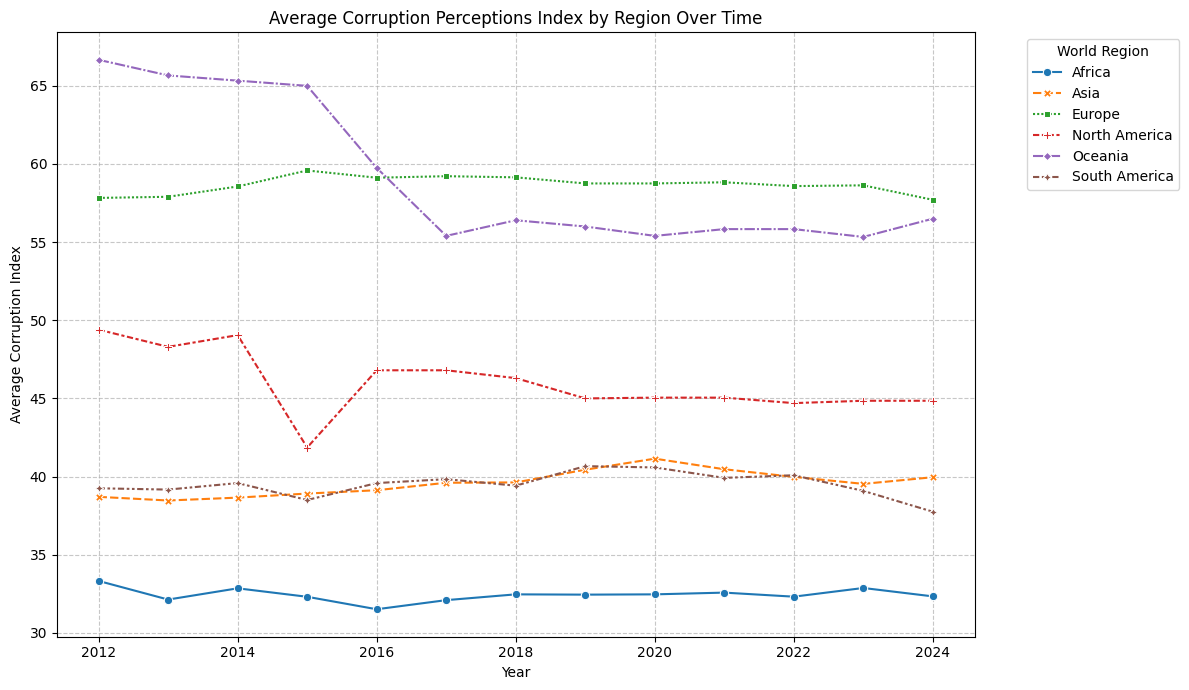

In [ ]:
plt.figure(figsize=(12, 7)) #12 inches wide and 7 inches tall
sns.lineplot(data=pivot_corruption, markers=True) #Using seaborn library to create line plot and add markers to each data point on lines
plt.title('Average Corruption Perceptions Index by Region Over Time') #Set the main title
plt.xlabel('Year') #Label xaxis as year
plt.ylabel('Average Corruption Index') #label yaxis as avr corruption index
plt.grid(True, linestyle='--', alpha=0.7) #adds a grid to the plot for easier reading of values
plt.legend(title='World Region', bbox_to_anchor=(1.05, 1), loc='upper left') #displays a legend to identify each line on the plot
plt.tight_layout() #automatically adjusts plot parameters for a tight layout
plt.show() #displays the generated plot

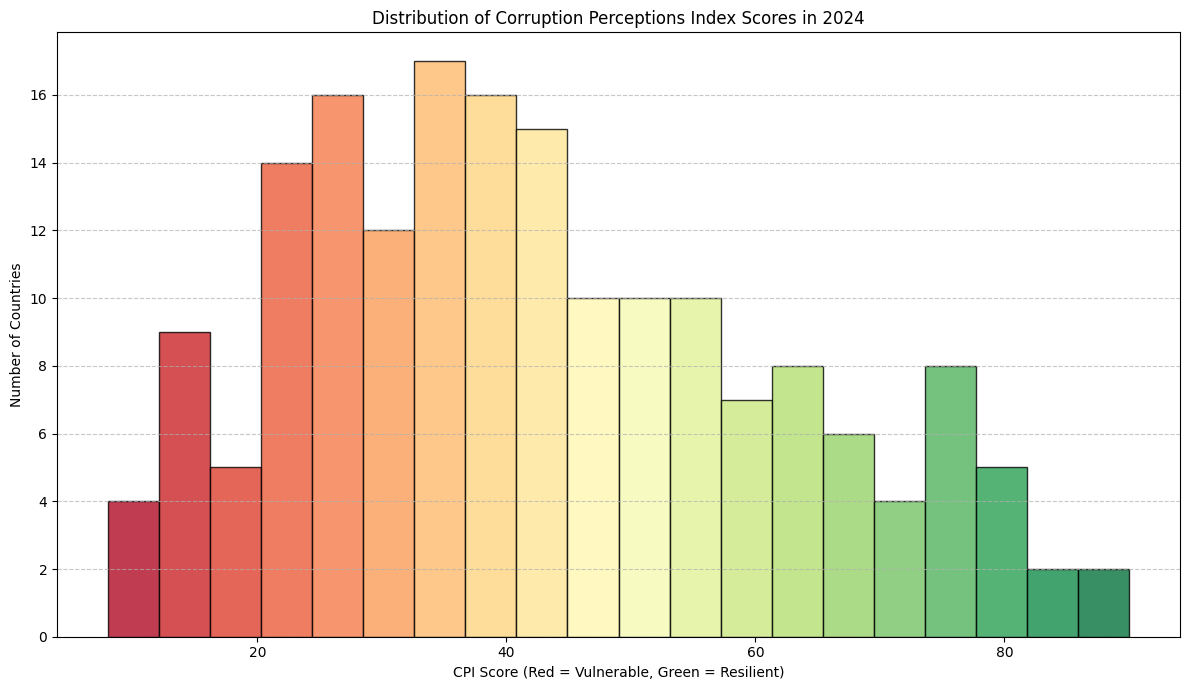

In [ ]:
latest_year = df_corruption['Year'].max()
df_latest_year = df_corruption[df_corruption['Year'] == latest_year]
cpi_scores = df_latest_year['Corruption Perceptions Index'].dropna()

plt.figure(figsize=(12, 7))

# Create the histogram. Using 20 bins to cover the 0-100 CPI score range.
n, bins, patches = plt.hist(cpi_scores, bins=20, edgecolor='black', alpha=0.8)

# Normalize scores for colormap (0 to 1) based on the full range of CPI scores
norm = plt.Normalize(vmin=cpi_scores.min(), vmax=cpi_scores.max())
cmap = plt.cm.RdYlGn  # Red for low scores, Yellow for middle, Green for high scores

# Apply color gradient to each bar based on the midpoint of its bin
for i, patch in enumerate(patches):
    color_value = (bins[i] + bins[i+1]) / 2 # Midpoint of the bin
    patch.set_facecolor(cmap(norm(color_value)))

plt.title(f'Distribution of Corruption Perceptions Index Scores in {latest_year}')
plt.xlabel('CPI Score (Red = Vulnerable, Green = Resilient)')
plt.ylabel('Number of Countries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1410/2442158472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='World region according to OWID', y='Corruption Perceptions Index', data=df_latest_year_corruption, palette='viridis')


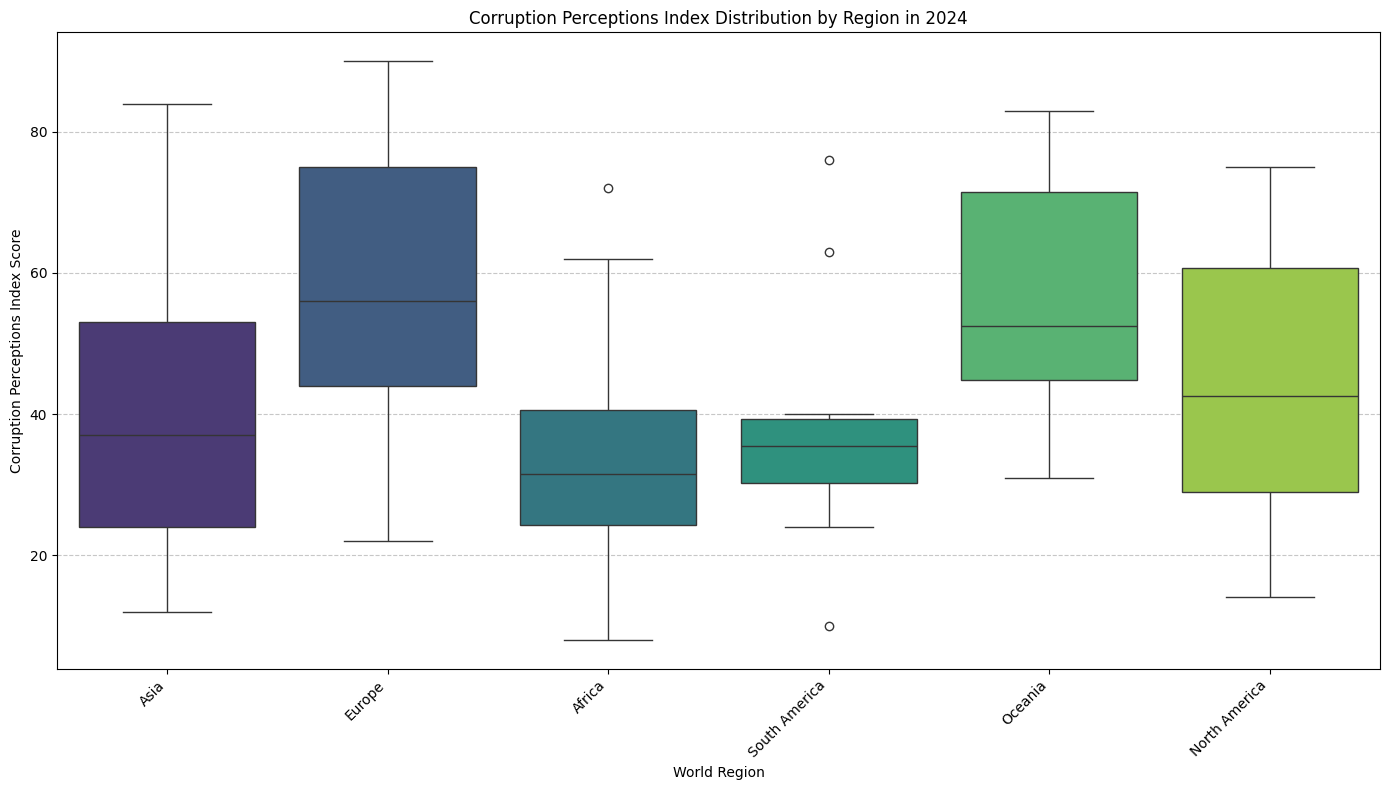

In [ ]:
# Filter data for the latest year
latest_year = df_corruption['Year'].max()
df_latest_year_corruption = df_corruption[df_corruption['Year'] == latest_year].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(x='World region according to OWID', y='Corruption Perceptions Index', data=df_latest_year_corruption, palette='viridis')
plt.title(f'Corruption Perceptions Index Distribution by Region in {latest_year}')
plt.xlabel('World Region')
plt.ylabel('Corruption Perceptions Index Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

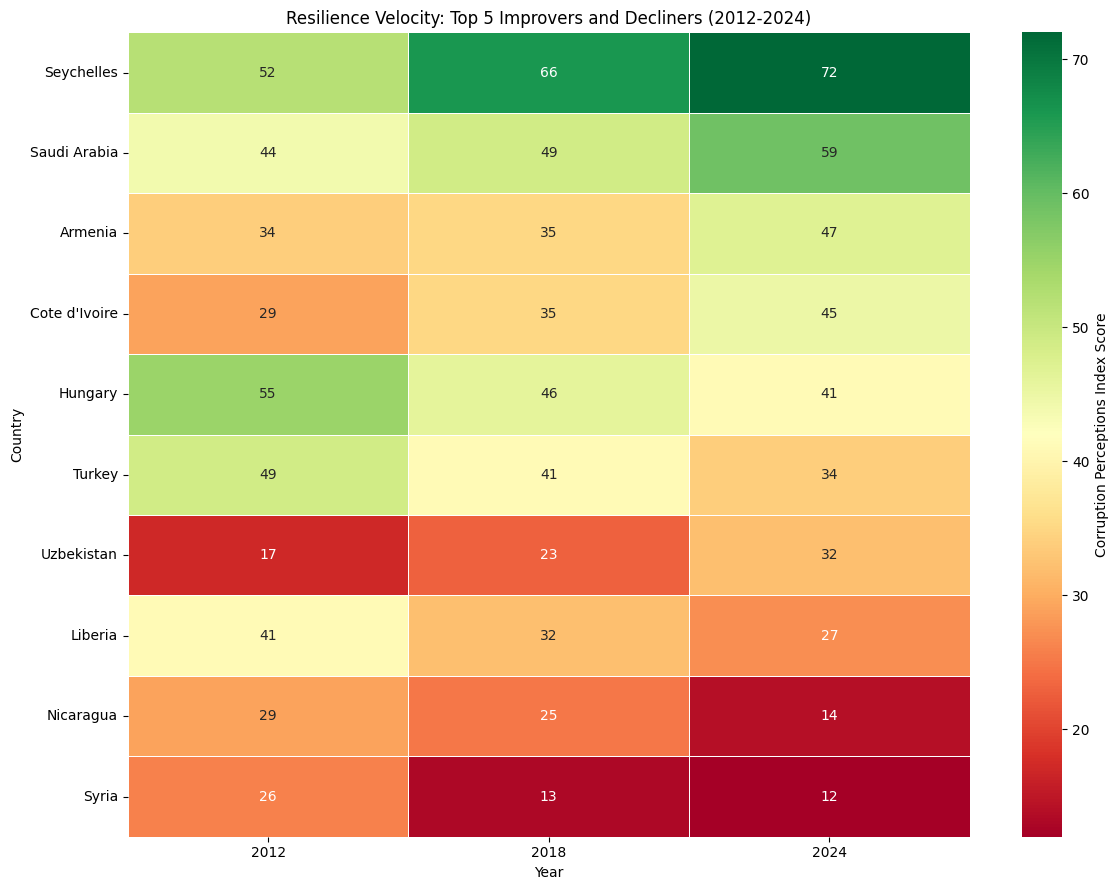

In [ ]:
# Filter for the years 2012, 2018, and 2024
years_to_plot = [2012, 2018, 2024]
df_filtered_years = df_corruption[df_corruption['Year'].isin(years_to_plot)].copy()

# Pivot the table to get years as columns for easier comparison
df_pivot = df_filtered_years.pivot_table(
    index='Entity',
    columns='Year',
    values='Corruption Perceptions Index'
).reset_index()

# Calculate the delta (difference) between 2024 and 2012
df_pivot['Delta'] = df_pivot[2024] - df_pivot[2012]

# Handle potential NaN values that could arise if a country is missing data for 2012 or 2024
df_pivot.dropna(subset=[2012, 2024, 'Delta'], inplace=True)

# Get the top 5 improvers (largest positive delta)
top_improvers = df_pivot.nlargest(5, 'Delta')

# Get the top 5 decliners (largest negative delta)
top_decliners = df_pivot.nsmallest(5, 'Delta')

# Combine the top improvers and decliners
df_heatmap_data = pd.concat([top_improvers, top_decliners])

# Prepare data for the heatmap, selecting only the relevant years and countries
heatmap_values = df_heatmap_data.set_index('Entity')[years_to_plot]

# Sort by 2024 CPI score for better organization (most resilient at the top)
heatmap_values_sorted = heatmap_values.reindex(df_heatmap_data.sort_values(2024, ascending=False)['Entity'])

plt.figure(figsize=(12, 9)) # Increased figure size for better clarity
# Create the heatmap
sns.heatmap(
    heatmap_values_sorted,
    annot=True,      # Show the CPI scores on the heatmap
    fmt='g',         # Format annotations as general numbers
    cmap='RdYlGn',   # Red for low (corrupt), Green for high (clean)
    linewidths=.5,   # Add lines between cells
    cbar_kws={'label': 'Corruption Perceptions Index Score'},
    annot_kws={'size': 10} # Adjust annotation font size
)

plt.title('Resilience Velocity: Top 5 Improvers and Decliners (2012-2024)')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()